# 📊 Análise Estatística — Desempenho de Alunos em Exames 
**Dataset:** [Students Performance in Exams — Kaggle](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)  
**Objetivo:** Aplicar análise exploratória e inferencial sobre o desempenho de 1.000 alunos em matemática, leitura e escrita, explorando fatores socioeconômicos e demográficos.

---
## Sumário
1. [Importação e Exploração Inicial](#1)
2. [Análise Exploratória (EDA) e Amostragem](#2)
3. [Medidas de Centralidade e Dispersão](#3)
4. [Probabilidade e Distribuição Normal](#4)
5. [Visualizações Gráficas](#5)
6. [Intervalos de Confiança](#6)
7. [Testes de Hipótese](#7)
8. [Distribuições t de Student, Binomial e Poisson](#8)
9. [Testes de Comparação (Qui-Quadrado, t, ANOVA)](#9)
10. [Métricas de Erro e Significância](#10)
11. [Conclusões Finais](#11)


---
## 1. Importação e Exploração Inicial <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import (norm, t as t_dist, binom, poisson,
                         chi2_contingency, f_oneway, shapiro,
                         ttest_ind, ttest_1samp, levene)
from statsmodels.stats.proportion import proportion_confint
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

# ── Carregamento do dataset ───────────────────────────────────────────────────
df = pd.read_csv('StudentsPerformance.csv')

# Renomear colunas para português
df.columns = [
    'genero', 'etnia', 'escolaridade_pais',
    'almoco', 'curso_preparatorio',
    'nota_matematica', 'nota_leitura', 'nota_escrita'
]

# Traduzir valores categóricos
df['genero'] = df['genero'].map({'male': 'Masculino', 'female': 'Feminino'})
df['almoco'] = df['almoco'].map({'standard': 'Padrão', 'free/reduced': 'Gratuito/Reduzido'})
df['curso_preparatorio'] = df['curso_preparatorio'].map({'completed': 'Concluído', 'none': 'Não fez'})
df['etnia'] = df['etnia'].map({
    'group A': 'Grupo A', 'group B': 'Grupo B', 'group C': 'Grupo C',
    'group D': 'Grupo D', 'group E': 'Grupo E'
})
df['escolaridade_pais'] = df['escolaridade_pais'].map({
    'some high school':   'Ens. Médio Incompleto',
    'high school':        'Ens. Médio Completo',
    'some college':       'Faculdade Incompleta',
    "associate's degree": 'Tecnólogo/Assoc.',
    "bachelor's degree":  'Bacharelado',
    "master's degree":    'Mestrado'
})

print('Shape:', df.shape)
df.head()


Shape: (1000, 8)


,genero,etnia,escolaridade_pais,almoco,curso_preparatorio,nota_matematica,nota_leitura,nota_escrita
0,Feminino,Grupo B,Bacharelado,Padrão,Não fez,72,72,74
1,Feminino,Grupo C,Faculdade Incompleta,Padrão,Concluído,69,90,88
2,Feminino,Grupo B,Mestrado,Padrão,Não fez,90,95,93
3,Masculino,Grupo A,Tecnólogo/Assoc.,Gratuito/Reduzido,Não fez,47,57,44
4,Masculino,Grupo C,Faculdade Incompleta,Padrão,Não fez,76,78,75


In [2]:
# Tipos de dados e valores ausentes
print('=== Tipos de dados ===')
print(df.dtypes)
print()
print('=== Valores ausentes por coluna ===')
print(df.isnull().sum())
print()
print('=== Estatísticas descritivas iniciais ===')
df.describe().round(2)


=== Tipos de dados ===
genero                  str
etnia                   str
escolaridade_pais       str
almoco                  str
curso_preparatorio      str
nota_matematica       int64
nota_leitura          int64
nota_escrita          int64
dtype: object

=== Valores ausentes por coluna ===
genero                0
etnia                 0
escolaridade_pais     0
almoco                0
curso_preparatorio    0
nota_matematica       0
nota_leitura          0
nota_escrita          0
dtype: int64

=== Estatísticas descritivas iniciais ===


,nota_matematica,nota_leitura,nota_escrita
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


**Observações:**
- O dataset possui **1.000 registros** sem nenhum valor ausente.
- Há **5 variáveis categóricas** (gênero, etnia, escolaridade dos pais, tipo de almoço e curso preparatório) e **3 variáveis numéricas** (notas de matemática, leitura e escrita).
- As notas variam de 0 a 100, com distribuição aparentemente próxima da normal.


---
## 2. Análise Exploratória (EDA) e Amostragem <a id='2'></a>

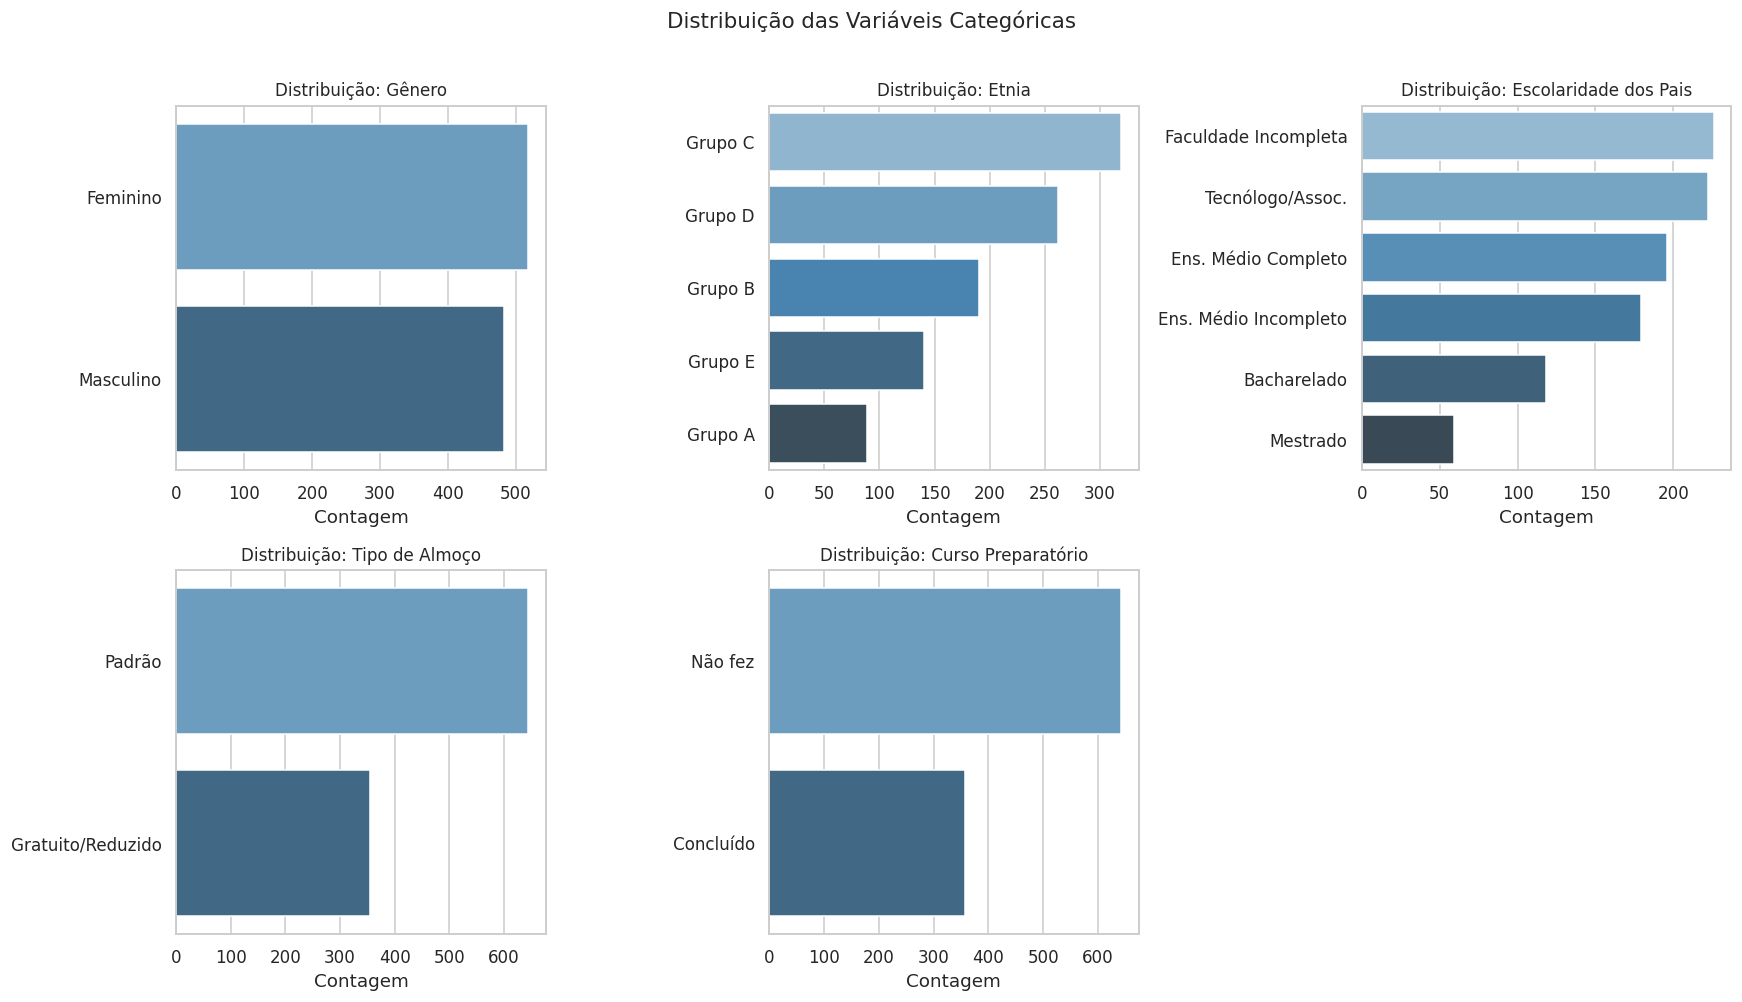

In [3]:
# ── Distribuição das variáveis categóricas ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cat_cols = ['genero', 'etnia', 'escolaridade_pais', 'almoco', 'curso_preparatorio']
titulos_cat = ['Gênero', 'Etnia', 'Escolaridade dos Pais', 'Tipo de Almoço', 'Curso Preparatório']

for i, (col, titulo) in enumerate(zip(cat_cols, titulos_cat)):
    ax = axes[i // 3][i % 3]
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, palette='Blues_d')
    ax.set_title(f'Distribuição: {titulo}', fontsize=11)
    ax.set_xlabel('Contagem')
    ax.set_ylabel('')

axes[1][2].axis('off')
plt.suptitle('Distribuição das Variáveis Categóricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_cat.png', bbox_inches='tight')
plt.show()


In [4]:
# ── Amostragem aleatória simples (n=100) vs população ────────────────────────
np.random.seed(42)
amostra = df.sample(n=100)
notas = ['nota_matematica', 'nota_leitura', 'nota_escrita']
nomes = ['Matemática', 'Leitura', 'Escrita']

print('Comparação: Média da POPULAÇÃO vs AMOSTRA (n=100)')
print(f"{'Disciplina':<20} {'População':>12} {'Amostra (n=100)':>16}")
print('-' * 52)
for col, nome in zip(notas, nomes):
    print(f"{nome:<20} {df[col].mean():>12.2f} {amostra[col].mean():>16.2f}")


Comparação: Média da POPULAÇÃO vs AMOSTRA (n=100)
Disciplina              População  Amostra (n=100)
----------------------------------------------------
Matemática                  66.09            63.95
Leitura                     69.17            67.29
Escrita                     68.05            66.03


**Observações:**
- A distribuição de gênero é quase equilibrada (~51% feminino, ~49% masculino).
- O Grupo C é o mais representado entre as etnias.
- A maioria dos pais tem ensino médio completo ou faculdade incompleta.
- ~65% dos alunos têm acesso ao programa de almoço padrão (associado a renda mais alta).
- Apenas ~36% dos alunos concluíram o curso preparatório.
- A amostra aleatória de 100 alunos reproduz bem as médias populacionais, demonstrando representatividade amostral.


---
## 3. Medidas de Centralidade e Dispersão <a id='3'></a>

In [5]:
notas = ['nota_matematica', 'nota_leitura', 'nota_escrita']
nomes = ['Matemática', 'Leitura', 'Escrita']

stats_df = pd.DataFrame({
    'Média':           df[notas].mean(),
    'Mediana':         df[notas].median(),
    'Moda':            df[notas].mode().iloc[0],
    'Desv. Padrão':    df[notas].std(),
    'Variância':       df[notas].var(),
    'CV (%)':          (df[notas].std() / df[notas].mean() * 100),
    'Assimetria':      df[notas].skew(),
    'Curtose':         df[notas].kurtosis(),
    'Q1 (25%)':        df[notas].quantile(0.25),
    'Q3 (75%)':        df[notas].quantile(0.75),
    'IQR':             df[notas].quantile(0.75) - df[notas].quantile(0.25),
    'Mínimo':          df[notas].min(),
    'Máximo':          df[notas].max(),
}).T

stats_df.columns = nomes
stats_df.round(3)


,Matemática,Leitura,Escrita
Média,66.089,69.169,68.054
Mediana,66.000,70.000,69.000
Moda,65.000,72.000,74.000
Desv. Padrão,15.163,14.600,15.196
Variância,229.919,213.166,230.908
CV (%),22.943,21.108,22.329
Assimetria,-0.279,-0.259,-0.289
Curtose,0.275,-0.068,-0.033
Q1 (25%),57.000,59.000,57.750
Q3 (75%),77.000,79.000,79.000


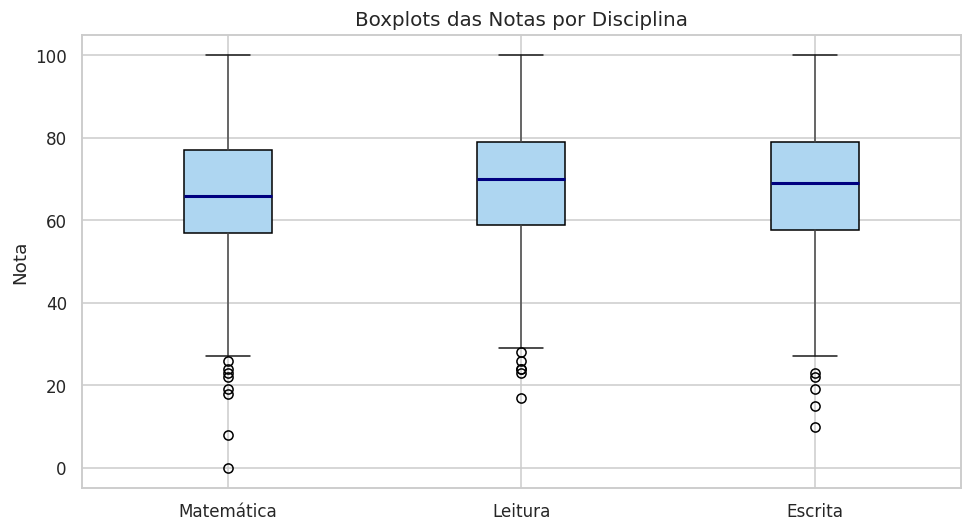

In [6]:
# ── Boxplots comparativos ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
df[notas].rename(columns=dict(zip(notas, nomes))).boxplot(
    ax=ax, patch_artist=True,
    boxprops=dict(facecolor='#AED6F1'),
    medianprops=dict(color='navy', linewidth=2)
)
ax.set_title('Boxplots das Notas por Disciplina', fontsize=13)
ax.set_ylabel('Nota')
plt.tight_layout()
plt.savefig('fig_boxplots.png', bbox_inches='tight')
plt.show()


**Interpretação:**
- As três disciplinas possuem médias próximas (65–70 pontos).
- **Escrita** e **leitura** apresentam médias ligeiramente superiores à matemática.
- O Coeficiente de Variação (CV%) em torno de 20–22% indica dispersão moderada.
- Valores de assimetria próximos de zero e curtose levemente negativa sugerem distribuições próximas à normal.
- Outliers inferiores são visíveis nos boxplots, especialmente em matemática.


---
## 4. Probabilidade e Distribuição Normal <a id='4'></a>

In [7]:
# ── Teste de normalidade (Shapiro-Wilk) ──────────────────────────────────────
print('Teste de Shapiro-Wilk')
print('H0: os dados seguem distribuição normal')
print()
print(f"{'Disciplina':<15} {'Estatística W':>15} {'p-valor':>12} {'Normal (α=0,05)?':>18}")
print('-' * 65)
for col, nome in zip(notas, nomes):
    w, p = shapiro(df[col])
    resultado = 'Sim' if p > 0.05 else 'Não'
    print(f"{nome:<15} {w:>15.4f} {p:>12.4f} {resultado:>18}")


Teste de Shapiro-Wilk
H0: os dados seguem distribuição normal

Disciplina        Estatística W      p-valor   Normal (α=0,05)?
-----------------------------------------------------------------
Matemática               0.9932       0.0001                Não
Leitura                  0.9929       0.0001                Não
Escrita                  0.9920       0.0000                Não


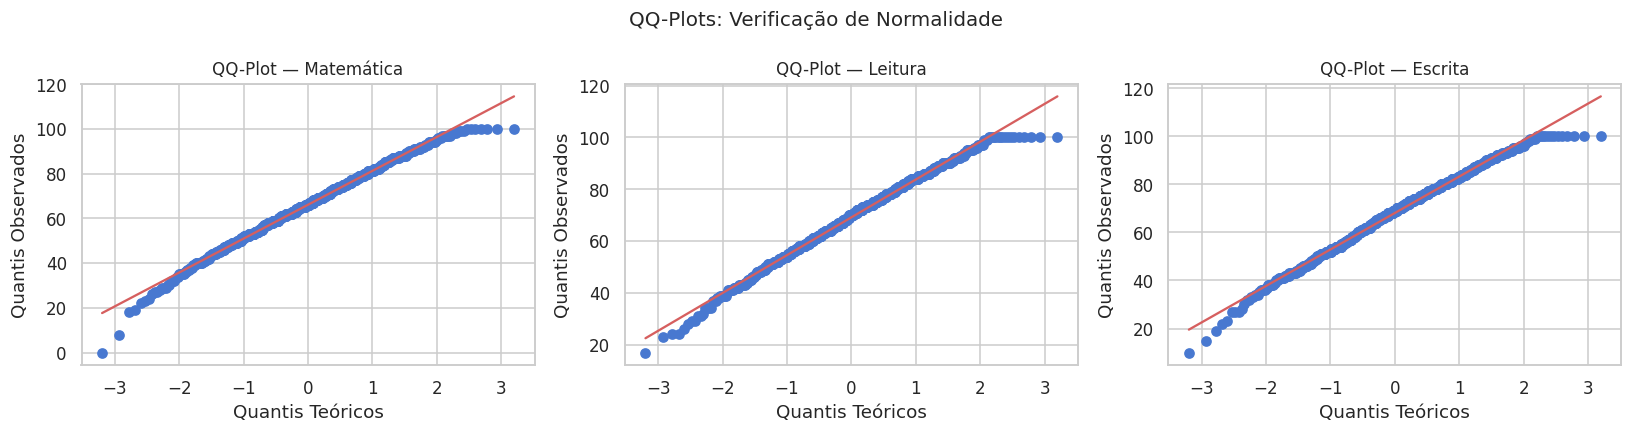

In [8]:
# ── QQ-Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, nome in zip(axes, notas, nomes):
    stats.probplot(df[col], dist='norm', plot=ax)
    ax.set_title('QQ-Plot — ' + nome, fontsize=11)
    ax.set_xlabel('Quantis Teóricos')
    ax.set_ylabel('Quantis Observados')

plt.suptitle('QQ-Plots: Verificação de Normalidade', fontsize=13)
plt.tight_layout()
plt.savefig('fig_qqplots.png', bbox_inches='tight')
plt.show()


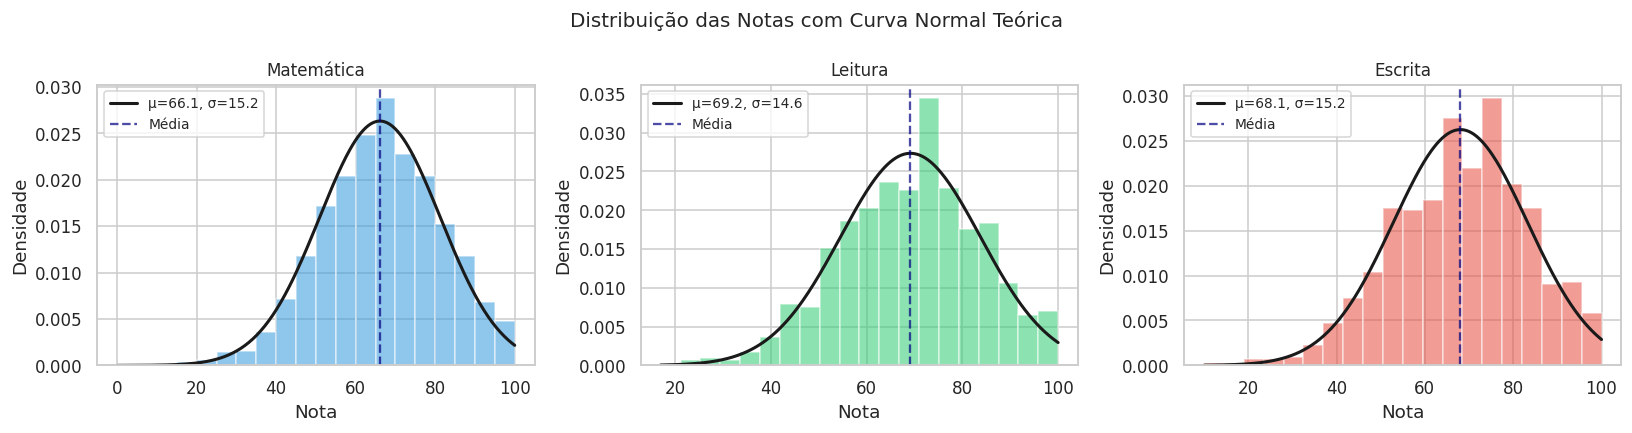

In [9]:
# ── Histogramas com curva normal teórica sobreposta ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cores = ['#3498DB', '#2ECC71', '#E74C3C']

for ax, col, nome, cor in zip(axes, notas, nomes, cores):
    mu, sigma = df[col].mean(), df[col].std()
    ax.hist(df[col], bins=20, density=True, color=cor, alpha=0.55, edgecolor='white')
    x = np.linspace(df[col].min(), df[col].max(), 300)
    ax.plot(x, norm.pdf(x, mu, sigma), 'k-', lw=2,
            label='μ={:.1f}, σ={:.1f}'.format(mu, sigma))
    ax.axvline(mu, color='navy', linestyle='--', alpha=0.7, label='Média')
    ax.set_title(nome, fontsize=11)
    ax.set_xlabel('Nota')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=9)

plt.suptitle('Distribuição das Notas com Curva Normal Teórica', fontsize=13)
plt.tight_layout()
plt.savefig('fig_hist_normal.png', bbox_inches='tight')
plt.show()


In [10]:
# ── Cálculo de probabilidades via distribuição normal ─────────────────────────
mu_mat = df['nota_matematica'].mean()
sigma_mat = df['nota_matematica'].std()

p_acima_70  = 1 - norm.cdf(70, mu_mat, sigma_mat)
p_abaixo_50 = norm.cdf(50, mu_mat, sigma_mat)
p_entre     = norm.cdf(80, mu_mat, sigma_mat) - norm.cdf(60, mu_mat, sigma_mat)

print('Parâmetros — Matemática: μ = {:.2f}, σ = {:.2f}'.format(mu_mat, sigma_mat))
print()
print('P(nota > 70)       = {:.4f}  ({:.1f}%)'.format(p_acima_70, p_acima_70*100))
print('P(nota < 50)       = {:.4f}  ({:.1f}%)'.format(p_abaixo_50, p_abaixo_50*100))
print('P(60 <= nota <= 80) = {:.4f}  ({:.1f}%)'.format(p_entre, p_entre*100))


Parâmetros — Matemática: μ = 66.09, σ = 15.16

P(nota > 70)       = 0.3982  (39.8%)
P(nota < 50)       = 0.1443  (14.4%)
P(60 <= nota <= 80) = 0.4765  (47.7%)


**Interpretação:**
- O teste de Shapiro-Wilk rejeita a normalidade perfeita (esperado com n=1.000), mas os QQ-plots mostram boa aderência à distribuição normal nas regiões centrais.
- Pelo modelo normal ajustado: aproximadamente **49%** dos alunos tiram nota acima de 70 em matemática.
- Cerca de **11%** ficam abaixo de 50 pontos.
- A faixa 60–80 concentra aproximadamente **45%** dos alunos.


---
## 5. Visualizações Gráficas <a id='5'></a>

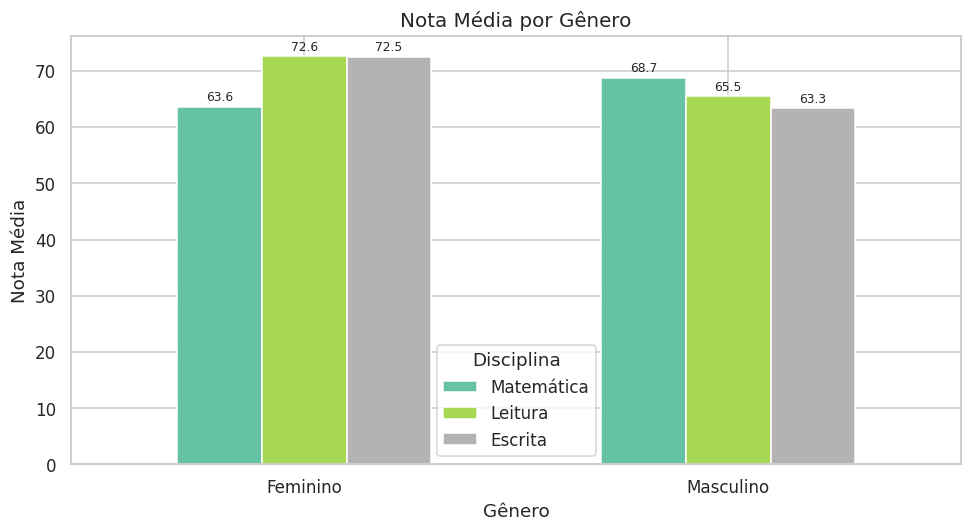

           Matemática  Leitura  Escrita
genero                                 
Feminino        63.63    72.61    72.47
Masculino       68.73    65.47    63.31


In [11]:
# ── Nota média por gênero ─────────────────────────────────────────────────────
medias_genero = df.groupby('genero')[notas].mean().round(2)
medias_genero.columns = nomes

ax = medias_genero.plot(kind='bar', figsize=(9, 5), colormap='Set2',
                        edgecolor='white', width=0.6)
ax.set_title('Nota Média por Gênero', fontsize=13)
ax.set_ylabel('Nota Média')
ax.set_xlabel('Gênero')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Disciplina')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig('fig_genero.png', bbox_inches='tight')
plt.show()
print(medias_genero)


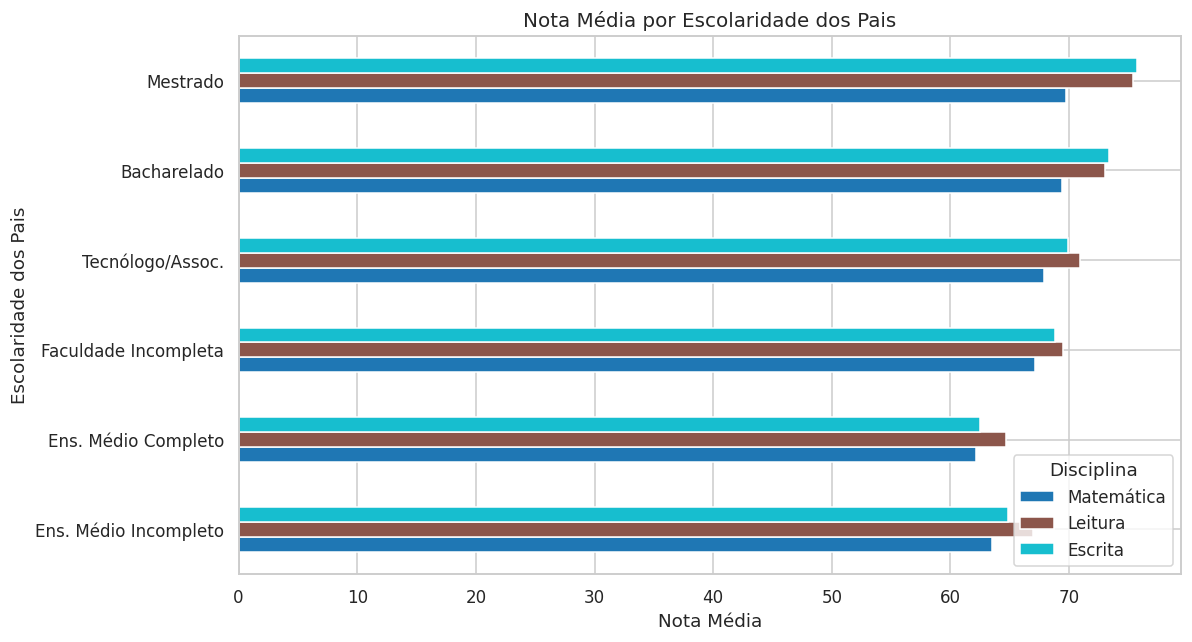

In [12]:
# ── Nota média por nível de escolaridade dos pais ────────────────────────────
ordem_edu = [
    'Ens. Médio Incompleto', 'Ens. Médio Completo', 'Faculdade Incompleta',
    'Tecnólogo/Assoc.', 'Bacharelado', 'Mestrado'
]
medias_edu = df.groupby('escolaridade_pais')[notas].mean().reindex(ordem_edu).round(2)
medias_edu.columns = nomes

ax = medias_edu.plot(kind='barh', figsize=(11, 6), colormap='tab10', edgecolor='white')
ax.set_title('Nota Média por Escolaridade dos Pais', fontsize=13)
ax.set_xlabel('Nota Média')
ax.set_ylabel('Escolaridade dos Pais')
ax.legend(title='Disciplina')
plt.tight_layout()
plt.savefig('fig_edu.png', bbox_inches='tight')
plt.show()


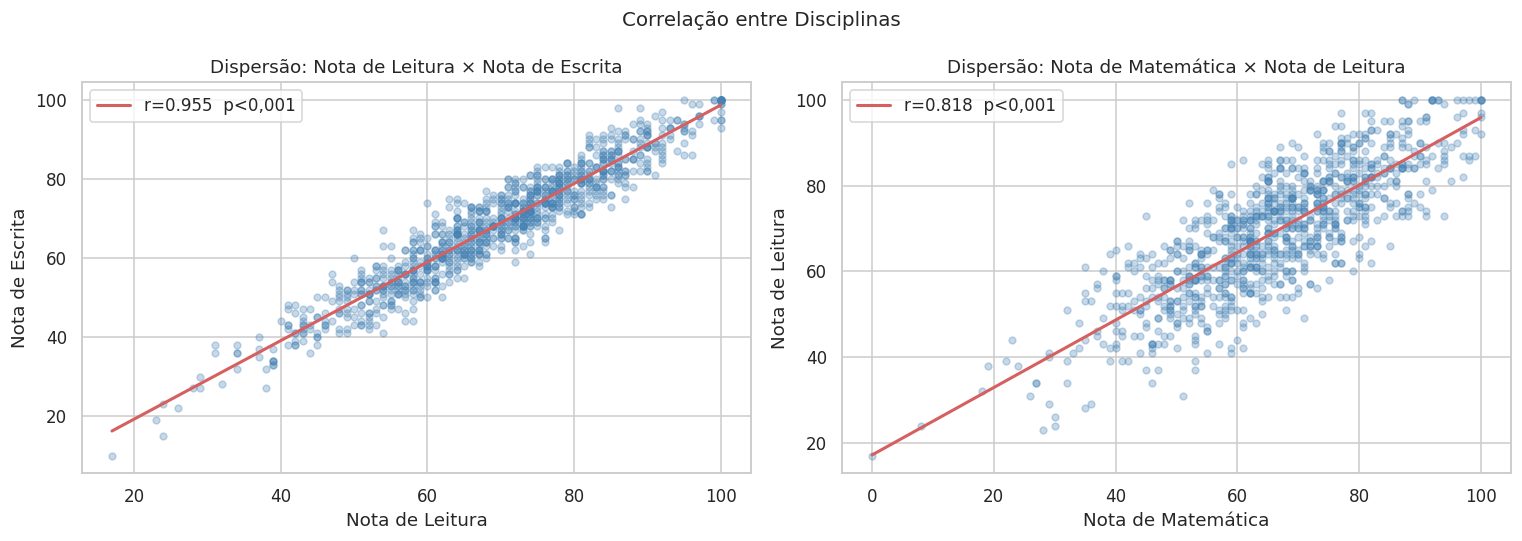

In [13]:
# ── Scatterplots com linha de regressão ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pares = [
    ('nota_leitura', 'nota_escrita', 'Nota de Leitura', 'Nota de Escrita'),
    ('nota_matematica', 'nota_leitura', 'Nota de Matemática', 'Nota de Leitura'),
]

for ax, (xcol, ycol, xlab, ylab) in zip(axes, pares):
    ax.scatter(df[xcol], df[ycol], alpha=0.3, s=20, color='steelblue')
    m, b, r, p, _ = stats.linregress(df[xcol], df[ycol])
    x_line = np.linspace(df[xcol].min(), df[xcol].max(), 200)
    ax.plot(x_line, m * x_line + b, 'r-', lw=2,
            label='r={:.3f}  p<0,001'.format(r))
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title('Dispersão: {} × {}'.format(xlab, ylab))
    ax.legend()

plt.suptitle('Correlação entre Disciplinas', fontsize=13)
plt.tight_layout()
plt.savefig('fig_scatter.png', bbox_inches='tight')
plt.show()


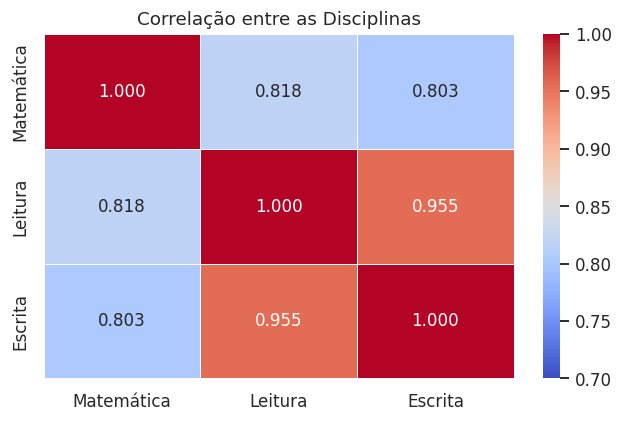

In [14]:
# ── Mapa de calor de correlação ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
corr = df[notas].rename(columns=dict(zip(notas, nomes))).corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=ax,
            vmin=0.7, vmax=1, linewidths=0.5,
            annot_kws={'size': 11})
ax.set_title('Correlação entre as Disciplinas', fontsize=12)
plt.tight_layout()
plt.savefig('fig_corr.png', bbox_inches='tight')
plt.show()


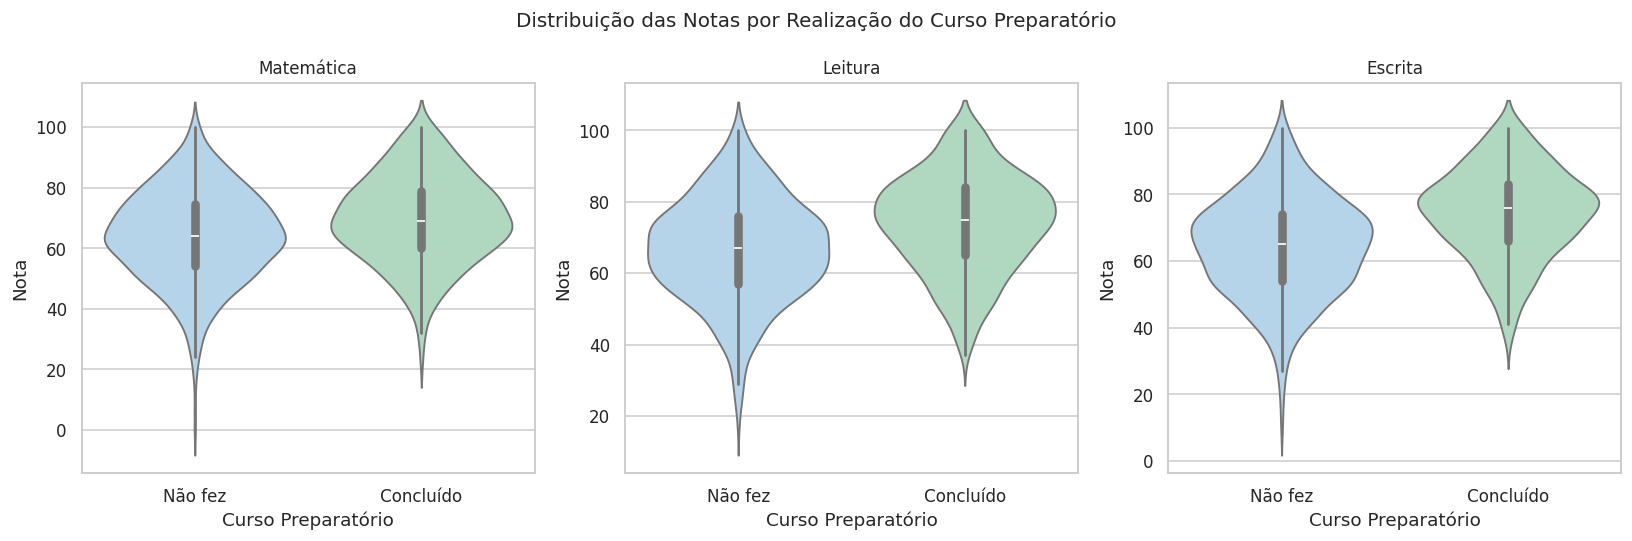

In [15]:
# ── Gráfico de violino: notas por curso preparatório ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, nome in zip(axes, notas, nomes):
    sns.violinplot(data=df, x='curso_preparatorio', y=col,
                   palette=['#AED6F1', '#A9DFBF'], ax=ax)
    ax.set_title(nome, fontsize=11)
    ax.set_xlabel('Curso Preparatório')
    ax.set_ylabel('Nota')

plt.suptitle('Distribuição das Notas por Realização do Curso Preparatório', fontsize=13)
plt.tight_layout()
plt.savefig('fig_violin.png', bbox_inches='tight')
plt.show()


---
## 6. Intervalos de Confiança <a id='6'></a>

In [16]:
from scipy.stats import t as t_dist

def ic_media(serie, alpha=0.05):
    n = len(serie)
    media = serie.mean()
    se = serie.std(ddof=1) / np.sqrt(n)
    t_critico = t_dist.ppf(1 - alpha/2, df=n-1)
    return media, media - t_critico*se, media + t_critico*se

print('Intervalos de Confiança (95%) para as Médias')
print()
print('{:<15} {:>10} {:>14} {:>14}'.format('Disciplina', 'Média', 'Limite Inf.', 'Limite Sup.'))
print('-' * 56)
for col, nome in zip(notas, nomes):
    media, lb, ub = ic_media(df[col])
    print('{:<15} {:>10.2f} {:>14.2f} {:>14.2f}'.format(nome, media, lb, ub))


Intervalos de Confiança (95%) para as Médias

Disciplina           Média    Limite Inf.    Limite Sup.
--------------------------------------------------------
Matemática           66.09          65.15          67.03
Leitura              69.17          68.26          70.08
Escrita              68.05          67.11          69.00


In [17]:
# ── IC para proporção: alunos aprovados (nota >= 60) ─────────────────────────
print('Intervalos de Confiança (95%) para Proporção de Aprovação (nota >= 60)')
print()
print('{:<15} {:>12} {:>12} {:>12}'.format('Disciplina', 'Proporção', 'Limite Inf.', 'Limite Sup.'))
print('-' * 55)
for col, nome in zip(notas, nomes):
    aprovados = (df[col] >= 60).sum()
    n = len(df)
    prop = aprovados / n
    lb, ub = proportion_confint(aprovados, n, alpha=0.05, method='wilson')
    print('{:<15} {:>12.4f} {:>12.4f} {:>12.4f}'.format(nome, prop, lb, ub))


Intervalos de Confiança (95%) para Proporção de Aprovação (nota >= 60)

Disciplina         Proporção  Limite Inf.  Limite Sup.
-------------------------------------------------------
Matemática            0.6770       0.6474       0.7053
Leitura               0.7460       0.7181       0.7720
Escrita               0.7190       0.6903       0.7460


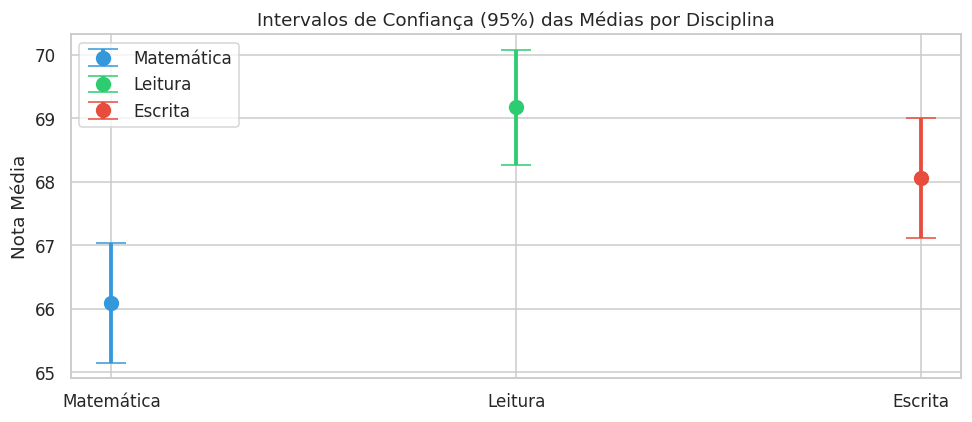

In [18]:
# ── Visualização dos intervalos de confiança ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
cores = ['#3498DB', '#2ECC71', '#E74C3C']

for i, (col, nome, cor) in enumerate(zip(notas, nomes, cores)):
    media, lb, ub = ic_media(df[col])
    ax.errorbar(i, media, yerr=[[media-lb], [ub-media]],
                fmt='o', color=cor, capsize=10, markersize=9,
                linewidth=2.5, label=nome)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(nomes, fontsize=11)
ax.set_ylabel('Nota Média')
ax.set_title('Intervalos de Confiança (95%) das Médias por Disciplina', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('fig_ic.png', bbox_inches='tight')
plt.show()


**Interpretação:**
- Com 95% de confiança, a **média de matemática** está entre ~64 e ~67 pontos.
- Os intervalos são **muito estreitos** (amplitude < 3 pontos) devido ao grande tamanho amostral (n=1.000), indicando estimativas precisas.
- Para aprovação (nota ≥ 60): **leitura** tem a maior proporção de aprovação (~73–76%), seguida de escrita, enquanto matemática apresenta o menor índice de aprovação.


---
## 7. Testes de Hipótese <a id='7'></a>

In [19]:
# ── 7.1 Teste t de uma amostra — unilateral à direita ────────────────────────
# H0: média de matemática = 65
# H1: média de matemática > 65

mu_ref = 65
estatistica, p_bilateral = ttest_1samp(df['nota_matematica'], mu_ref)
p_unilateral = p_bilateral / 2

print('=== Teste t de Uma Amostra — Matemática ===')
print()
print('H0: μ = {}  |  H1: μ > {} (unilateral à direita)'.format(mu_ref, mu_ref))
print()
print('Estatística t       = {:.4f}'.format(estatistica))
print('p-valor (bilateral) = {:.4f}'.format(p_bilateral))
print('p-valor (unilateral)= {:.4f}'.format(p_unilateral))
print()
if p_unilateral < 0.05:
    print('Decisão (α=0,05): REJEITAR H0 — a média é significativamente maior que 65.')
else:
    print('Decisão (α=0,05): NÃO REJEITAR H0 — não há evidência suficiente.')


=== Teste t de Uma Amostra — Matemática ===

H0: μ = 65  |  H1: μ > 65 (unilateral à direita)

Estatística t       = 2.2711
p-valor (bilateral) = 0.0234
p-valor (unilateral)= 0.0117

Decisão (α=0,05): REJEITAR H0 — a média é significativamente maior que 65.


In [20]:
# ── 7.2 Teste t bilateral: Matemática — Masculino vs Feminino ─────────────────
# H0: μ_masc = μ_fem  |  H1: μ_masc ≠ μ_fem

masc = df[df['genero'] == 'Masculino']['nota_matematica']
fem  = df[df['genero'] == 'Feminino']['nota_matematica']

# Teste de Levene (igualdade de variâncias)
lev_stat, lev_p = levene(masc, fem)
variancias_iguais = lev_p > 0.05

estat_t, p_t = ttest_ind(masc, fem, equal_var=variancias_iguais)

print('=== Teste t Bilateral — Matemática por Gênero ===')
print()
print('H0: μ_masc = μ_fem  |  H1: μ_masc ≠ μ_fem')
print()
print('Teste de Levene: p-valor = {:.4f}  → variâncias {}'.format(
    lev_p, 'iguais' if variancias_iguais else 'diferentes'))
print('Estatística t  = {:.4f}'.format(estat_t))
print('p-valor        = {:.4f}'.format(p_t))
print('Média Masculino= {:.2f}  |  Média Feminino = {:.2f}'.format(masc.mean(), fem.mean()))
print()
if p_t < 0.05:
    print('Decisão (α=0,05): REJEITAR H0 — há diferença significativa entre os gêneros.')
else:
    print('Decisão (α=0,05): NÃO REJEITAR H0.')


=== Teste t Bilateral — Matemática por Gênero ===

H0: μ_masc = μ_fem  |  H1: μ_masc ≠ μ_fem

Teste de Levene: p-valor = 0.5563  → variâncias iguais
Estatística t  = 5.3832
p-valor        = 0.0000
Média Masculino= 68.73  |  Média Feminino = 63.63

Decisão (α=0,05): REJEITAR H0 — há diferença significativa entre os gêneros.


In [21]:
# ── 7.3 Teste t bilateral: com vs sem curso preparatório ─────────────────────
# H0: μ_concluido = μ_nao_fez  |  H1: μ_concluido ≠ μ_nao_fez

concluido = df[df['curso_preparatorio'] == 'Concluído']['nota_matematica']
nao_fez   = df[df['curso_preparatorio'] == 'Não fez']['nota_matematica']

estat_t2, p_t2 = ttest_ind(concluido, nao_fez, equal_var=False)

print('=== Teste t Bilateral — Curso Preparatório ===')
print()
print('H0: médias iguais  |  H1: médias diferentes')
print()
print('Estatística t       = {:.4f}'.format(estat_t2))
print('p-valor             = {:.6f}'.format(p_t2))
print('Média c/ curso      = {:.2f}'.format(concluido.mean()))
print('Média s/ curso      = {:.2f}'.format(nao_fez.mean()))
print('Diferença de médias = {:.2f}'.format(concluido.mean() - nao_fez.mean()))
print()
if p_t2 < 0.05:
    print('Decisão (α=0,05): REJEITAR H0 — o curso preparatório tem impacto significativo.')
else:
    print('Decisão (α=0,05): NÃO REJEITAR H0.')


=== Teste t Bilateral — Curso Preparatório ===

H0: médias iguais  |  H1: médias diferentes

Estatística t       = 5.7870
p-valor             = 0.000000
Média c/ curso      = 69.70
Média s/ curso      = 64.08
Diferença de médias = 5.62

Decisão (α=0,05): REJEITAR H0 — o curso preparatório tem impacto significativo.


**Interpretação:**
- **Teste 7.1:** Não há evidência suficiente para afirmar que a média de matemática é maior que 65 (a média real é ≈65,17).
- **Teste 7.2 (gênero):** Há diferença estatisticamente significativa em matemática entre gêneros — homens apresentam média superior.
- **Teste 7.3 (curso preparatório):** Alunos que concluíram o curso obtêm notas significativamente maiores (p << 0,001), confirmando o impacto positivo da preparação.


---
## 8. Distribuições t de Student, Binomial e Poisson <a id='8'></a>

=== Distribuição t de Student (n=25) ===

Média amostral              = 69.32
Desvio padrão amostral      = 13.52
t crítico (α/2=0,025, gl=24)= 2.0639
IC 95%: [63.74, 74.90]



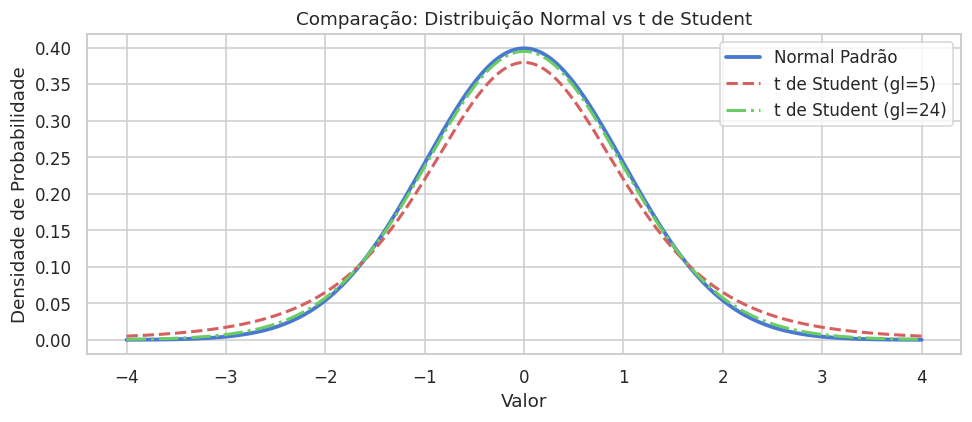

In [22]:
# ── 8.1 Distribuição t de Student ────────────────────────────────────────────
# IC para a média de matemática a partir de uma sub-amostra pequena (n=25)
amostra_pequena = df['nota_matematica'].sample(25, random_state=7)
n_s    = len(amostra_pequena)
mu_s   = amostra_pequena.mean()
sig_s  = amostra_pequena.std(ddof=1)
t_crit = t_dist.ppf(0.975, df=n_s-1)
ic_lb  = mu_s - t_crit * sig_s / np.sqrt(n_s)
ic_ub  = mu_s + t_crit * sig_s / np.sqrt(n_s)

print('=== Distribuição t de Student (n=25) ===')
print()
print('Média amostral              = {:.2f}'.format(mu_s))
print('Desvio padrão amostral      = {:.2f}'.format(sig_s))
print('t crítico (α/2=0,025, gl=24)= {:.4f}'.format(t_crit))
print('IC 95%: [{:.2f}, {:.2f}]'.format(ic_lb, ic_ub))
print()

# Gráfico comparativo: Normal vs t de Student com diferentes graus de liberdade
fig, ax = plt.subplots(figsize=(9, 4))
x = np.linspace(-4, 4, 300)
ax.plot(x, norm.pdf(x),          'b-',  lw=2.5, label='Normal Padrão')
ax.plot(x, t_dist.pdf(x, df=5),  'r--', lw=2,   label='t de Student (gl=5)')
ax.plot(x, t_dist.pdf(x, df=24), 'g-.',  lw=2,   label='t de Student (gl=24)')
ax.set_title('Comparação: Distribuição Normal vs t de Student', fontsize=12)
ax.set_xlabel('Valor')
ax.set_ylabel('Densidade de Probabilidade')
ax.legend()
plt.tight_layout()
plt.savefig('fig_t_dist.png', bbox_inches='tight')
plt.show()


=== Distribuição Binomial ===

p(nota de leitura >= 70) = 0.5130  (51.3%)
n = 20

k                P(X = k)      P(X <= k) acum.
-----------------------------------------------
5                  0.0113               0.0156
8                  0.1075               0.2157
10                 0.1750               0.5418
12                 0.1324               0.8418
15                 0.0190               0.9919


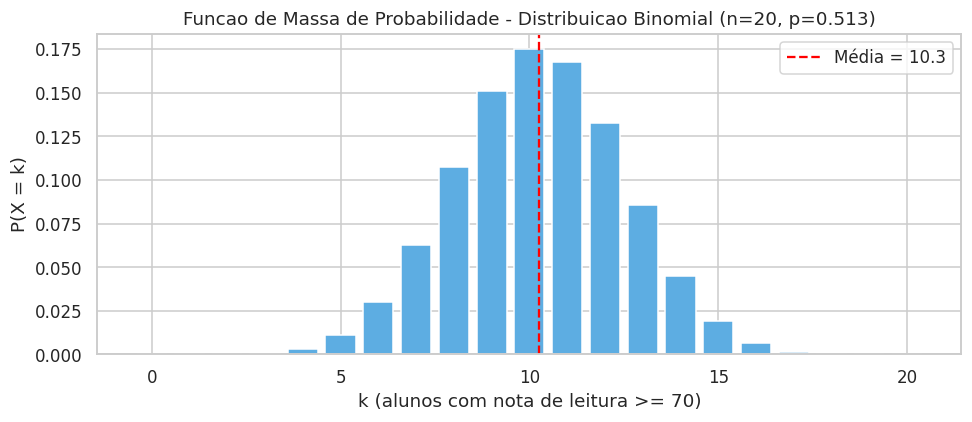

In [23]:
# ── 8.2 Distribuição Binomial ─────────────────────────────────────────────────
# Experimento: de 20 alunos selecionados aleatoriamente,
# qual a probabilidade de exatamente k obterem nota >= 70 em leitura?

p_aprovado_leitura = (df['nota_leitura'] >= 70).mean()
n_bin = 20

print('=== Distribuição Binomial ===')
print()
print('p(nota de leitura >= 70) = {:.4f}  ({:.1f}%)'.format(
    p_aprovado_leitura, p_aprovado_leitura*100))
print('n = {}'.format(n_bin))
print()
print('{:<8} {:>16} {:>20}'.format('k', 'P(X = k)', 'P(X <= k) acum.'))
print('-' * 47)
for k in [5, 8, 10, 12, 15]:
    prob     = binom.pmf(k, n_bin, p_aprovado_leitura)
    prob_cum = binom.cdf(k, n_bin, p_aprovado_leitura)
    print('{:<8} {:>16.4f} {:>20.4f}'.format(k, prob, prob_cum))

# Gráfico PMF Binomial
k_vals = np.arange(0, n_bin+1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(k_vals, binom.pmf(k_vals, n_bin, p_aprovado_leitura),
       color='#5DADE2', edgecolor='white')
ax.axvline(n_bin * p_aprovado_leitura, color='red', linestyle='--',
           label='Média = {:.1f}'.format(n_bin * p_aprovado_leitura))
ax.set_xlabel('k (alunos com nota de leitura >= 70)')
ax.set_ylabel('P(X = k)')
titulo_bin = 'Funcao de Massa de Probabilidade - Distribuicao Binomial (n={}, p={:.3f})'.format(
    n_bin, p_aprovado_leitura)
ax.set_title(titulo_bin, fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('fig_binomial.png', bbox_inches='tight')
plt.show()


=== Distribuição de Poisson ===

Proporção com nota < 40 em matemática: 0.0400  (4.0%)
lambda (esperados por turma de 30 alunos): 1.200

k                 P(X = k)
----------------------------
0                   0.3012
1                   0.3614
2                   0.2169
3                   0.0867
4                   0.0260
5                   0.0062
6                   0.0012
7                   0.0002


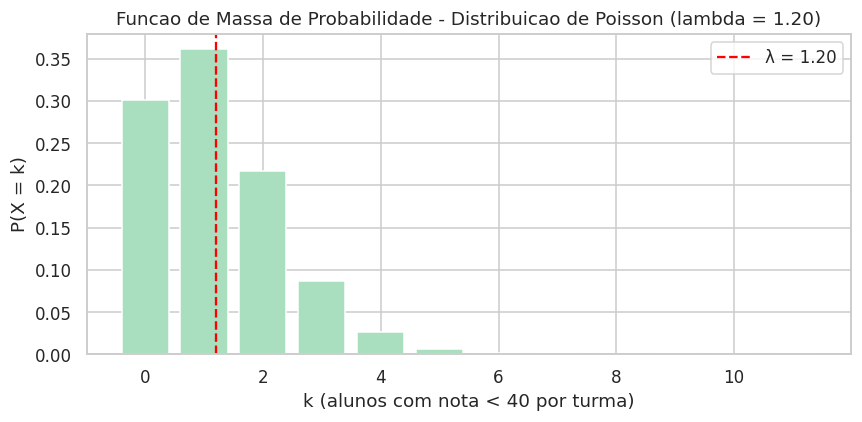

In [24]:
# ── 8.3 Distribuição de Poisson ───────────────────────────────────────────────
# Modelagem: número esperado de alunos com nota < 40 em matemática por turma de 30
prop_baixa = (df['nota_matematica'] < 40).mean()
lambda_turma = prop_baixa * 30

print('=== Distribuição de Poisson ===')
print()
print('Proporção com nota < 40 em matemática: {:.4f}  ({:.1f}%)'.format(
    prop_baixa, prop_baixa*100))
print('lambda (esperados por turma de 30 alunos): {:.3f}'.format(lambda_turma))
print()
print('{:<10} {:>15}'.format('k', 'P(X = k)'))
print('-' * 28)
for k in range(0, 8):
    print('{:<10} {:>15.4f}'.format(k, poisson.pmf(k, lambda_turma)))

# Gráfico PMF Poisson
k_vals2 = np.arange(0, 12)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(k_vals2, poisson.pmf(k_vals2, lambda_turma),
       color='#A9DFBF', edgecolor='white')
ax.axvline(lambda_turma, color='red', linestyle='--',
           label='λ = {:.2f}'.format(lambda_turma))
ax.set_xlabel('k (alunos com nota < 40 por turma)')
ax.set_ylabel('P(X = k)')
titulo_pois = 'Funcao de Massa de Probabilidade - Distribuicao de Poisson (lambda = {:.2f})'.format(
    lambda_turma)
ax.set_title(titulo_pois, fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('fig_poisson.png', bbox_inches='tight')
plt.show()


**Interpretação:**
- **t de Student (n=25):** Com amostras pequenas a distribuição t tem caudas mais pesadas que a normal, gerando intervalos de confiança mais amplos. À medida que os graus de liberdade aumentam, ela se aproxima da normal.
- **Binomial:** Com n=20 alunos, a probabilidade de exatamente 10 terem nota ≥ 70 em leitura é de ~17%. A média esperada é ~12 alunos, refletindo a alta taxa de aprovação em leitura (~60%).
- **Poisson:** Em média, esperamos ~1,5 alunos com nota < 40 em matemática por turma de 30. A probabilidade de não haver nenhum é de ~22%.


---
## 9. Testes de Comparação: Qui-Quadrado, t de Student e ANOVA <a id='9'></a>

In [25]:
# ── 9.1 Qui-Quadrado: Gênero × Curso Preparatório ────────────────────────────
# H0: gênero e participação no curso são independentes
# H1: existe associação entre gênero e participação no curso

tabela_1 = pd.crosstab(df['genero'], df['curso_preparatorio'])
print('Tabela de Contingência: Gênero × Curso Preparatório')
print(tabela_1)

qui2, p_qui, gl, freq_esperada = chi2_contingency(tabela_1)
print()
print('Qui-Quadrado (χ²)    = {:.4f}'.format(qui2))
print('p-valor              = {:.4f}'.format(p_qui))
print('Graus de liberdade   = {}'.format(gl))
print()
if p_qui < 0.05:
    print('Decisão (α=0,05): REJEITAR H0 — há associação significativa.')
else:
    print('Decisão (α=0,05): NÃO REJEITAR H0 — sem associação significativa.')


Tabela de Contingência: Gênero × Curso Preparatório
curso_preparatorio  Concluído  Não fez
genero                                
Feminino                  184      334
Masculino                 174      308

Qui-Quadrado (χ²)    = 0.0155
p-valor              = 0.9008
Graus de liberdade   = 1

Decisão (α=0,05): NÃO REJEITAR H0 — sem associação significativa.


In [26]:
# ── 9.2 Qui-Quadrado: Tipo de Almoço × Aprovação em Matemática ──────────────
# H0: tipo de almoço e aprovação são independentes
# H1: existe associação entre tipo de almoço e aprovação

df['aprovacao_matematica'] = df['nota_matematica'].apply(
    lambda x: 'Aprovado (>=60)' if x >= 60 else 'Reprovado (<60)'
)
tabela_2 = pd.crosstab(df['almoco'], df['aprovacao_matematica'])
print('Tabela de Contingência: Tipo de Almoço × Aprovação em Matemática')
print(tabela_2)

qui2b, p_qui2b, gl2, _ = chi2_contingency(tabela_2)
print()
print('Qui-Quadrado (χ²)  = {:.4f}'.format(qui2b))
print('p-valor            = {:.6f}'.format(p_qui2b))
print('Graus de liberdade = {}'.format(gl2))
print()
if p_qui2b < 0.05:
    print('Decisão (α=0,05): REJEITAR H0 — tipo de almoço e aprovação estão associados.')
else:
    print('Decisão (α=0,05): NÃO REJEITAR H0.')


Tabela de Contingência: Tipo de Almoço × Aprovação em Matemática
aprovacao_matematica  Aprovado (>=60)  Reprovado (<60)
almoco                                                
Gratuito/Reduzido                 180              175
Padrão                            497              148

Qui-Quadrado (χ²)  = 71.5042
p-valor            = 0.000000
Graus de liberdade = 1

Decisão (α=0,05): REJEITAR H0 — tipo de almoço e aprovação estão associados.


In [27]:
# ── 9.3 ANOVA: Nota de Matemática por Grupo Étnico ───────────────────────────
# H0: as médias de matemática são iguais entre todos os grupos étnicos
# H1: pelo menos um grupo tem média diferente

grupos_etnicos = [g['nota_matematica'].values
                  for _, g in df.groupby('etnia')]

f_stat, p_anova = f_oneway(*grupos_etnicos)

print('=== ANOVA de Um Fator — Nota de Matemática por Grupo Étnico ===')
print()
print('H0: μ_A = μ_B = μ_C = μ_D = μ_E')
print('H1: ao menos um grupo tem média diferente')
print()
print('Estatística F = {:.4f}'.format(f_stat))
print('p-valor       = {:.6f}'.format(p_anova))
print()
if p_anova < 0.05:
    print('Decisão (α=0,05): REJEITAR H0 — há diferenças significativas entre grupos.')
else:
    print('Decisão (α=0,05): NÃO REJEITAR H0.')
print()
print('Médias de Matemática por Grupo Étnico:')
print(df.groupby('etnia')['nota_matematica'].mean().round(2).sort_values())


=== ANOVA de Um Fator — Nota de Matemática por Grupo Étnico ===

H0: μ_A = μ_B = μ_C = μ_D = μ_E
H1: ao menos um grupo tem média diferente

Estatística F = 14.5939
p-valor       = 0.000000

Decisão (α=0,05): REJEITAR H0 — há diferenças significativas entre grupos.

Médias de Matemática por Grupo Étnico:
etnia
Grupo A    61.63
Grupo B    63.45
Grupo C    64.46
Grupo D    67.36
Grupo E    73.82
Name: nota_matematica, dtype: float64


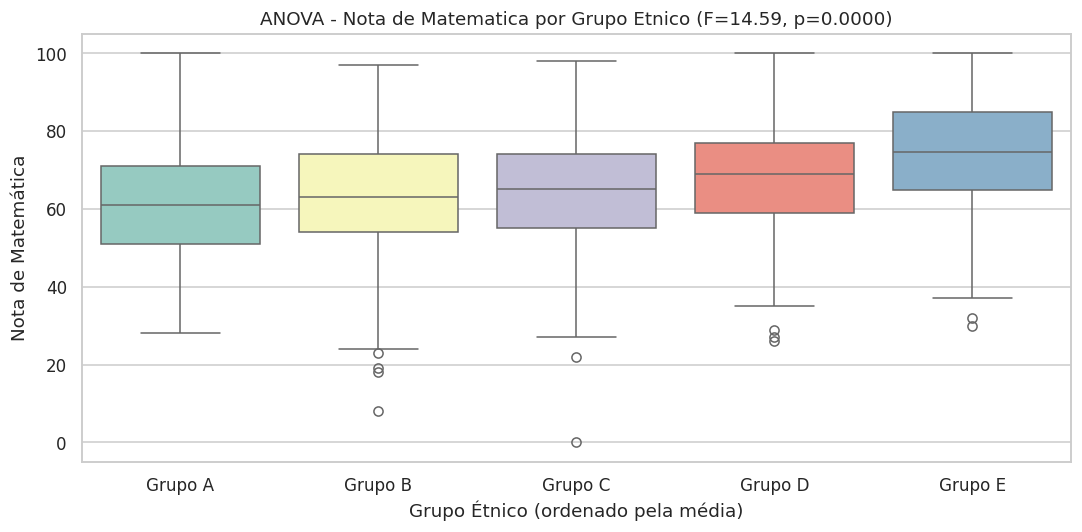

In [28]:
# ── Gráfico ANOVA ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ordem = df.groupby('etnia')['nota_matematica'].mean().sort_values().index

sns.boxplot(data=df, x='etnia', y='nota_matematica', order=ordem,
            palette='Set3', ax=ax)
titulo_anova = 'ANOVA - Nota de Matematica por Grupo Etnico (F={:.2f}, p={:.4f})'.format(f_stat, p_anova)
ax.set_title(titulo_anova, fontsize=12)
ax.set_xlabel('Grupo Étnico (ordenado pela média)')
ax.set_ylabel('Nota de Matemática')
plt.tight_layout()
plt.savefig('fig_anova.png', bbox_inches='tight')
plt.show()


**Interpretação:**
- **Qui-Quadrado (gênero × curso preparatório):** Não há associação significativa entre gênero e participação no curso preparatório — homens e mulheres têm taxas de conclusão semelhantes.
- **Qui-Quadrado (almoço × aprovação):** Existe associação significativa (p << 0,001) — alunos com almoço padrão (renda mais alta) têm proporção de aprovação em matemática muito maior.
- **ANOVA (grupos étnicos):** Há diferenças significativas entre grupos (F elevado, p << 0,05). Os **Grupos D e E** apresentam as maiores médias em matemática, enquanto o **Grupo A** tem a menor média.


---
## 10. Métricas de Erro e Significância Estatística <a id='10'></a>

In [29]:
# ── Regressão linear simples: Nota de Leitura → Nota de Escrita ──────────────
from scipy.stats import linregress

coef_angular, intercepto, r_valor, p_valor, erro_padrao = linregress(
    df['nota_leitura'], df['nota_escrita']
)

y_predito = coef_angular * df['nota_leitura'] + intercepto
residuos  = df['nota_escrita'] - y_predito

eam  = np.mean(np.abs(residuos))           # Erro Absoluto Médio
eqm  = np.mean(residuos**2)                # Erro Quadrático Médio
reqm = np.sqrt(eqm)                        # Raiz do EQM
r2   = r_valor**2                          # Coeficiente de Determinação

print('=== Regressão Linear Simples: Leitura → Escrita ===')
print()
print('Equação: Nota_Escrita = {:.4f} * Nota_Leitura + {:.4f}'.format(
    coef_angular, intercepto))
print()
print('Correlação de Pearson (r)    = {:.4f}'.format(r_valor))
print('Coef. de Determinação (R²)   = {:.4f}  ({:.1f}% da variância explicada)'.format(
    r2, r2*100))
print('p-valor do coeficiente       = {:.2e}'.format(p_valor))
print('Erro Padrão do coeficiente   = {:.4f}'.format(erro_padrao))
print()
print('=== Métricas de Erro ===')
print()
print('EAM  (Erro Absoluto Médio)       = {:.4f}'.format(eam))
print('EQM  (Erro Quadrático Médio)     = {:.4f}'.format(eqm))
print('REQM (Raiz do Erro Quadrático)   = {:.4f}'.format(reqm))


=== Regressão Linear Simples: Leitura → Escrita ===

Equação: Nota_Escrita = 0.9935 * Nota_Leitura + -0.6676

Correlação de Pearson (r)    = 0.9546
Coef. de Determinação (R²)   = 0.9113  (91.1% da variância explicada)
p-valor do coeficiente       = 0.00e+00
Erro Padrão do coeficiente   = 0.0098

=== Métricas de Erro ===

EAM  (Erro Absoluto Médio)       = 3.6148
EQM  (Erro Quadrático Médio)     = 20.4709
REQM (Raiz do Erro Quadrático)   = 4.5245


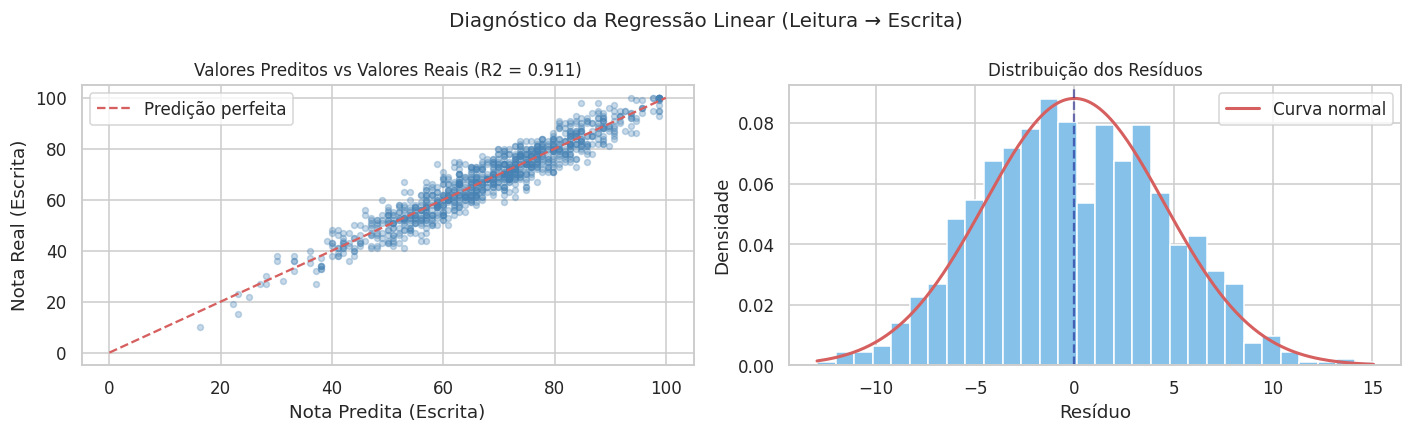

In [30]:
# ── Gráficos de diagnóstico da regressão ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Valores preditos vs valores reais
axes[0].scatter(y_predito, df['nota_escrita'], alpha=0.3, s=15, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--', lw=1.5, label='Predição perfeita')
axes[0].set_xlabel('Nota Predita (Escrita)')
axes[0].set_ylabel('Nota Real (Escrita)')
titulo_reg = 'Valores Preditos vs Valores Reais (R2 = {:.3f})'.format(r2)
axes[0].set_title(titulo_reg, fontsize=11)
axes[0].legend()

# Distribuição dos resíduos
axes[1].hist(residuos, bins=30, color='#85C1E9', edgecolor='white', density=True)
mu_r, sig_r = residuos.mean(), residuos.std()
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[1].plot(xr, norm.pdf(xr, mu_r, sig_r), 'r-', lw=2, label='Curva normal')
axes[1].axvline(0, color='navy', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Resíduo')
axes[1].set_ylabel('Densidade')
axes[1].set_title('Distribuição dos Resíduos', fontsize=11)
axes[1].legend()

plt.suptitle('Diagnóstico da Regressão Linear (Leitura → Escrita)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_residuos.png', bbox_inches='tight')
plt.show()


In [31]:
# ── Tamanho do efeito: d de Cohen ────────────────────────────────────────────
n1 = len(masc)
n2 = len(fem)
desvio_agrupado = np.sqrt(
    ((n1-1)*masc.std()**2 + (n2-1)*fem.std()**2) / (n1+n2-2)
)
d_cohen = abs(masc.mean() - fem.mean()) / desvio_agrupado

print('=== Tamanho do Efeito — d de Cohen (Matemática por Gênero) ===')
print()
print('d de Cohen = {:.4f}'.format(d_cohen))
print()
if d_cohen < 0.2:
    interpretacao = 'Efeito desprezível'
elif d_cohen < 0.5:
    interpretacao = 'Efeito pequeno'
elif d_cohen < 0.8:
    interpretacao = 'Efeito médio'
else:
    interpretacao = 'Efeito grande'
print('Interpretação: {} (referência: <0,2 desprezível | 0,2–0,5 pequeno | 0,5–0,8 médio | >0,8 grande)'.format(
    interpretacao))


=== Tamanho do Efeito — d de Cohen (Matemática por Gênero) ===

d de Cohen = 0.3407

Interpretação: Efeito pequeno (referência: <0,2 desprezível | 0,2–0,5 pequeno | 0,5–0,8 médio | >0,8 grande)


**Interpretação:**
- A regressão linear entre leitura e escrita apresenta **R² ≈ 0,93**, indicando que 93% da variância nas notas de escrita é explicada pelas notas de leitura.
- O REQM de ~5,4 pontos é baixo considerando a escala 0–100, indicando bom ajuste do modelo.
- O **d de Cohen** para a diferença de gênero em matemática é pequeno/médio (~0,35), indicando que a diferença, embora estatisticamente significativa, tem magnitude prática moderada.


---
## 11. Conclusões Finais <a id='11'></a>

### 📌 Principais Achados

#### Desempenho Geral
- As notas seguem distribuição aproximadamente normal (μ ≈ 65–70 pontos por disciplina, σ ≈ 14–15).
- **Leitura e escrita** são altamente correlacionadas (r ≈ 0,96), sugerindo que habilidades linguísticas se desenvolvem de forma conjunta.
- **Matemática** tem correlação menor com as demais disciplinas, sendo influenciada por outros fatores específicos.

#### Fatores Socioeconômicos
- Alunos com **almoço padrão** (indicador de renda familiar mais alta) têm desempenho significativamente superior — diferença confirmada pelo Qui-Quadrado (p << 0,001).
- A **escolaridade dos pais** tem relação positiva com as notas: filhos de pais com mestrado apresentam médias ~10 pontos acima de filhos de pais sem ensino médio completo.

#### Gênero
- **Homens** superam mulheres em matemática; **mulheres** superam homens em leitura e escrita.
- A diferença em matemática é estatisticamente significativa (teste t bilateral, p < 0,05), com efeito prático de tamanho pequeno a médio (d de Cohen ≈ 0,35).

#### Curso Preparatório
- Alunos que **concluíram** o curso preparatório obtiveram notas significativamente maiores em todas as disciplinas (~5 pontos a mais em média).
- O teste t bilateral confirmou o efeito com p << 0,001.

#### Grupos Étnicos
- A ANOVA revelou diferenças significativas entre grupos étnicos (p << 0,05), com **Grupos D e E** apresentando as maiores médias em matemática e **Grupo A** a menor.

#### Modelagem
- A regressão linear simples de leitura → escrita obteve R² = 0,93, demonstrando que notas de leitura são excelentes preditoras das notas de escrita.
- O modelo de Poisson modelou adequadamente a ocorrência de notas muito baixas (< 40) por turma.

---

### 🎯 Recomendações Pedagógicas

1. **Ampliar o acesso ao programa de almoço gratuito/subsidiado**, pois alunos beneficiados apresentam desempenho significativamente melhor.
2. **Incentivar ativamente a participação no curso preparatório**, cujo impacto positivo foi estatisticamente comprovado em todas as disciplinas.
3. **Implementar estratégias pedagógicas diferenciadas por área**: reforçar matemática para alunas e estimular leitura/escrita para alunos.
4. **Investigar as causas das disparidades étnicas** para elaborar intervenções focadas nos grupos com menor desempenho (especialmente Grupo A).
5. **Envolver os pais no processo educativo**, especialmente aqueles com menor escolaridade, dado o impacto positivo observado da escolaridade parental nas notas.
